# CivicPulse Gauteng  Political Geography, Deprivation And Voter Participation
### DIRISA Student Datathon Challenge 2026 · Teams Qualification Submission

**Problem statement.** To what extent do multi-dimensional deprivation (Stats SA Census 2022) and ward-level party dominance (IEC 2016/2021) explain differences in voter participation, especially youth participation, across the City of Johannesburg and City of Tshwane ahead of the 4 November 2026 Local Government Elections?

### Why it matters, and to whom
- **IEC and civil society:** where to aim registration and turnout drives before 4 November 2026.
- **Political parties:** whether safe seats demobilise their own supporters.
- **Journalists:** evidence to test the generic "youth apathy" narrative.
- **Municipalities:** whether service-delivery failures carry a civic cost.

### Hypotheses
- **H1 - Deprivation friction:** structural deprivation (water, housing, refuse) lowers participation.
- **H2 - Incumbency demobilisation:** one-party dominance lowers turnout; voters disengage rather than defect.



---
## 1. Setup And Reproducibility

In [13]:
import os, re, json, hashlib, warnings, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, RidgeCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, r2_score, roc_auc_score, balanced_accuracy_score
from sklearn.inspection import permutation_importance
import joblib
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

warnings.filterwarnings('ignore')
RNG = 42
np.random.seed(RNG)
sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 40)
RESULTS = {}          

# Environment Package versions 
pkgs = ['pandas', 'numpy', 'scipy', 'statsmodels', 'sklearn', 'xgboost', 'matplotlib', 'seaborn', 'joblib']
print({p: getattr(importlib.import_module(p), '__version__', '?') for p in pkgs if importlib.util.find_spec(p)})

{'pandas': '2.2.3', 'numpy': '2.1.3', 'scipy': '1.16.3', 'statsmodels': '0.15.0', 'sklearn': '1.6.1', 'xgboost': '3.4.1', 'matplotlib': '3.10.0', 'seaborn': '0.13.2', 'joblib': '1.6.0'}


### Environment And Path Setup
Mount Google Drive to resolve workspace paths and configure output directories.

In [14]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass
CANDIDATES = [os.environ.get('CIVICPULSE_DATA', ''), '/content/drive/MyDrive/CivicPulse_Gauteng_2026/data/',
              '/mnt/user-data/uploads/', './data/', './']
BASE_DIR = next(d for d in CANDIDATES if d and os.path.exists(os.path.join(d, '2021_GP_municipal_election.csv')))
OUT_DIR = os.path.join(BASE_DIR if os.access(BASE_DIR, os.W_OK) else '.', 'civicpulse_outputs')
if not os.access(os.path.dirname(OUT_DIR.rstrip('/')) or '.', os.W_OK):
    OUT_DIR = './civicpulse_outputs'
os.makedirs(OUT_DIR, exist_ok=True)
print('Data folder  :', BASE_DIR)
print('Output folder:', OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data folder  : /content/drive/MyDrive/CivicPulse_Gauteng_2026/data/
Output folder: /content/drive/MyDrive/CivicPulse_Gauteng_2026/data/civicpulse_outputs


---
## 2. Data Collection And Audit

### Data Sources And Catalog

| Source | Description | File(s) |
| :--- | :--- | :--- |
| **IEC 2021 LGE Results** | Gauteng Municipal Election Data | `2021_GP_municipal_election.csv` |
| **IEC 2016 LGE Results** | Historical Baseline Election Data | `2016_GP_municipal_election.csv` |
| **Stats SA Census 2022** | Ward-level indicators (Water, Housing, Refuse, Age) | `AccessToPipedWaters_*.csv`, `dwelling_type_*.csv`, etc. |

In [15]:
CENSUS_FILES = {
    'water':  {'Johannesburg': 'AccessToPipedWaters_Johannesburg.csv', 'Tshwane': 'AccessToPipedWaters_tshwane.csv'},
    'dwell':  {'Johannesburg': 'dwelling_type_Johannesburg.csv',       'Tshwane': 'dwelling_type_tshwane.csv'},
    'refuse': {'Johannesburg': 'RefuseDisposals_Johannesburg.csv',     'Tshwane': 'RefuseDisposals_tshwane.csv'},
    'age':    {'Johannesburg': 'AgeGroups_Johannesburg.csv',           'Tshwane': 'AgeGroups_Tshwane.csv'},
}
F2021, F2016 = '2021_GP_municipal_election.csv', '2016_GP_municipal_election.csv'
md5 = lambda p: hashlib.md5(open(p, 'rb').read()).hexdigest()[:10]

audit = []
for f in sorted(x for x in os.listdir(BASE_DIR) if x.endswith('.csv')):
    p = os.path.join(BASE_DIR, f)
    row = {'file': f, 'size_kb': round(os.path.getsize(p) / 1024, 1), 'md5': md5(p)}
    if re.match(r'20\d\d_GP_municipal_election', f):
        row.update({'geo_level': 'Voting district x party x ballot'})
    else:
        try:
            d = pd.read_csv(p, encoding='utf-8-sig')
            row.update({'rows': len(d), 'geo_level': ', '.join(map(str, d['geoLevelDesc'].unique())) if 'geoLevelDesc' in d else '?',
                        'areas': d['geoLevelValueDesc'].nunique() if 'geoLevelValueDesc' in d else None})
        except Exception as e:
            row['geo_level'] = f'unreadable: {e}'
    audit.append(row)
audit = pd.DataFrame(audit)
display(audit)

dupes = audit[audit.duplicated('md5', keep=False)]
if len(dupes):
    print('Identical files (ignored beyond the first):', dupes.file.tolist())

def census_level(layer):
    levels = set()
    for metro, f in CENSUS_FILES[layer].items():
        p = os.path.join(BASE_DIR, f)
        if os.path.exists(p):
            levels |= set(pd.read_csv(p, encoding='utf-8-sig')['geoLevelDesc'].astype(str).str.lower())
    return levels
WARD_CENSUS = all(any('ward' in l for l in census_level(layer)) for layer in CENSUS_FILES)
HAS_2016 = os.path.exists(os.path.join(BASE_DIR, F2016))
print(f'Ward-level Census available : {WARD_CENSUS}  -> H1 with Census ' + ('ENABLED' if WARD_CENSUS else 'disabled (files are municipality-level)'))
print(f'2016 results available      : {HAS_2016}  -> H2 over time + 2026 forecast ' + ('ENABLED' if HAS_2016 else 'disabled'))
RESULTS.update({'ward_census': WARD_CENSUS, 'has_2016': HAS_2016})

,file,size_kb,md5,geo_level,rows,areas
0,2016_GP_municipal_election.csv,"13,548.2000",840e5a95da,Voting district x party x ballot,NaN,NaN
1,2021_GP_municipal_election.csv,"26,853.9000",e2521ea8d0,Voting district x party x ballot,NaN,NaN
2,AccessToPipedWaters_Johannesburg.csv,0.5000,d1d5c7add3,Municipality,4.0000,1.0000
3,AccessToPipedWaters_tshwane.csv,0.4000,6bd1c94345,Municipality,4.0000,1.0000
4,AgeGroups_Johannesburg.csv,1.6000,aff5b11b26,Municipality,18.0000,1.0000
5,AgeGroups_Tshwane.csv,1.5000,a2df00e0cb,Municipality,18.0000,1.0000
6,Copy of AgeGroups_Johannesburg.csv,1.6000,aff5b11b26,Municipality,18.0000,1.0000
7,RefuseDisposals_Johannesburg.csv,0.7000,f4b81eb78d,Municipality,7.0000,1.0000
8,RefuseDisposals_tshwane.csv,0.6000,6547cda299,Municipality,7.0000,1.0000
9,dwelling_type_Johannesburg.csv,0.4000,23fd09ab23,Municipality,4.0000,1.0000


Identical files (ignored beyond the first): ['AgeGroups_Johannesburg.csv', 'Copy of AgeGroups_Johannesburg.csv']
Ward-level Census available : False  -> H1 with Census disabled (files are municipality-level)
2016 results available      : True  -> H2 over time + 2026 forecast ENABLED


---
## 3. Cleaning And Harmonisation

### 3.1 IEC Results Preprocessing
* Filter for Johannesburg (JHB) and Tshwane (TSH) municipalities using ward ID prefixes.
* Isolate Ward ballots (excluding PR and DC ballots to prevent double-counting).
* Deduplicate registered voter and spoilt ballot counts per voting district (VD).
* Exclude invalid voting districts where total votes exceed registered voters.
* Aggregate metrics to ward level prior to merging.


In [16]:
ABBR = {'AFRICAN NATIONAL CONGRESS': 'ANC', 'DEMOCRATIC ALLIANCE': 'DA', 'ECONOMIC FREEDOM FIGHTERS': 'EFF',
        'ACTIONSA': 'ActionSA', 'VRYHEIDSFRONT PLUS': 'FF+', 'FREEDOM FRONT PLUS': 'FF+', 'PATRIOTIC ALLIANCE': 'PA',
        'INKATHA FREEDOM PARTY': 'IFP', 'INDEPENDENT': 'IND', 'AFRICAN CHRISTIAN DEMOCRATIC PARTY': 'ACDP',
        'AL JAMA-AH': 'AlJama'}

def process_iec(path, label):
    raw = pd.read_csv(path, encoding='utf-8-sig')
    raw.columns = [c.strip() for c in raw.columns]
    n0 = len(raw)
    df = raw[raw['Municipality'].astype(str).str.upper().str.startswith(('JHB', 'TSH'))
             & raw['BallotType'].astype(str).str.lower().eq('ward')].copy()
    df['ward_id'] = df['Ward'].astype(str).str.extract(r'(\d{8})')[0]
    df['metro'] = np.where(df['ward_id'].str.startswith('798'), 'Johannesburg', 'Tshwane')
    df['party'] = df['PartyName'].astype(str).str.upper().str.strip().map(ABBR).fillna('Other')
    vd = (df.groupby('VotingDistrict')
            .agg(ward_id=('ward_id', 'first'), metro=('metro', 'first'), station=('VotingStationName', 'first'),
                 registered=('RegisteredVoters', 'max'), spoilt=('SpoiltVotes', 'max'), valid=('TotalValidVotes', 'sum'))
            .reset_index())
    vd['turnout'] = (vd['valid'] + vd['spoilt']) / vd['registered']
    bad = (vd['registered'] <= 0) | (vd['turnout'] > 1)
    print(f'[{label}] raw rows {n0:,} -> metro Ward-ballot rows {len(df):,}; VDs {len(vd):,}; '
          f'excluded {bad.sum()} impossible VDs (votes > roll or 0 registered)')
    excluded = vd[bad].copy()
    vd = vd[~bad].copy()
    df = df[df['VotingDistrict'].isin(vd['VotingDistrict'])]
    return df, vd, excluded

df21, vd21, excl21 = process_iec(os.path.join(BASE_DIR, F2021), '2021')
display(excl21[['VotingDistrict', 'ward_id', 'station', 'registered', 'valid', 'spoilt']])
print('Wards per metro:', vd21.groupby('metro').ward_id.nunique().to_dict(), '(official 2021: 135 JHB, 107 TSH)')

[2021] raw rows 195,424 -> metro Ward-ballot rows 45,086; VDs 1,645; excluded 5 impossible VDs (votes > roll or 0 registered)


,VotingDistrict,ward_id,station,registered,valid,spoilt
659,32863574,79800003,SEIPONE PRIMARY SCHOOL,208,248,6
663,32863619,79800006,OLD POLICE STATION,299,385,11
666,32863642,79800121,ROCK OF FAITH MINISTRIES INTERNATIONAL,380,605,21
815,32871540,79800127,JERUSALEM RUGBY CLUB HALL,54,132,8
1461,33170217,79900099,FOUNTAIN OF LIFE CHURCH,133,137,3


Wards per metro: {'Johannesburg': 135, 'Tshwane': 107} (official 2021: 135 JHB, 107 TSH)


In [17]:
def ward_table(df, vd, key='ward_id'):
    '''Aggregate VD rows to wards and compute party-system measures.'''
    pv = df.pivot_table(index=key, columns='party', values='TotalValidVotes', aggfunc='sum', fill_value=0)
    share = pv.div(pv.sum(axis=1), axis=0)
    w = vd.groupby(key).agg(metro=('metro', 'first'), registered=('registered', 'sum'), valid=('valid', 'sum'),
                            spoilt=('spoilt', 'sum'), n_vd=('VotingDistrict', 'count'))
    w['turnout'] = (w['valid'] + w['spoilt']) / w['registered']
    w['spoilt_rate'] = w['spoilt'] / (w['valid'] + w['spoilt'])
    s = np.sort(share.values, axis=1)[:, ::-1]
    w['winner'] = share.idxmax(axis=1)
    w['winner_share'] = s[:, 0]
    w['margin'] = s[:, 0] - s[:, 1]
    w['enp'] = 1 / (share ** 2).sum(axis=1)
    for p in ['ANC', 'DA', 'EFF', 'ActionSA']:
        w[f'share_{p}'] = share[p] if p in share else 0.0
    w['winner_grp'] = w['winner'].where(w['winner'].isin(['ANC', 'DA']), 'Other')
    return w, share

wt, share21 = ward_table(df21, vd21)
wt = wt.reset_index()
print('Ward table:', wt.shape)
display(pd.crosstab(wt.metro, wt.winner, margins=True))

Ward table: (242, 17)


winner,ANC,AlJama,DA,IFP,PA,All
metro,,,,,,
Johannesburg,87,1,43,2,2,135
Tshwane,70,0,37,0,0,107
All,157,1,80,2,2,242


### 3.2 Census 2022 Harmonisation And Preprocessing
* Parse numeric counts from Stats SA SuperCross/Portal exports with fallback handling for demographic breakdowns (`countsMales` / `countsFemales`).
* Extract standard 8-digit Ward IDs using regex filtering for Johannesburg (`798`) and Tshwane (`799`).


In [18]:
def portal_value(d):
    v = pd.to_numeric(d.get('counts'), errors='coerce')
    if v.fillna(0).eq(0).all() and 'countsMales' in d:
        v = pd.to_numeric(d['countsMales'], errors='coerce') + pd.to_numeric(d['countsFemales'], errors='coerce')
    if v.fillna(0).eq(0).all():
        v = pd.to_numeric(d['countsPercentage'], errors='coerce')
    return v

def portal_ward_id(txt, metro):
    digits = re.findall(r'\d+', str(txt))
    full = [x for x in digits if len(x) == 8 and x[:3] in ('798', '799')]
    if full:
        return full[0]
    if digits and len(digits[-1]) <= 3:
        return ('798' if metro == 'Johannesburg' else '799') + digits[-1].zfill(5)
    return np.nan

def load_census_layer(layer):
    parts = []
    for metro, f in CENSUS_FILES[layer].items():
        d = pd.read_csv(os.path.join(BASE_DIR, f), encoding='utf-8-sig')
        d['value'] = portal_value(d)
        d['area'] = d['geoLevelValueDesc'].apply(lambda t: portal_ward_id(t, metro)) if WARD_CENSUS else metro
        parts.append(d[['area', 'label', 'value']])
    wide = pd.concat(parts).pivot_table(index='area', columns='label', values='value', aggfunc='sum')
    return wide

census = {layer: load_census_layer(layer) for layer in CENSUS_FILES}

def share_of(wide, pattern, invert=False):
    cols = [c for c in wide.columns if re.search(pattern, str(c), re.I)]
    s = wide[cols].sum(axis=1) / wide.sum(axis=1)
    return (1 - s) if invert else s, cols

def age_between(wide, a, b):
    tot = 0
    for c in wide.columns:
        nums = [int(x) for x in re.findall(r'\d+', str(c))]
        lo, hi = (nums[0], nums[1]) if len(nums) >= 2 else (nums[0], 110)
        ov = max(0, min(hi, b) - max(lo, a) + 1)
        if ov:
            tot = tot + wide[c].fillna(0) * ov / (hi - lo + 1)
    return tot

cf = pd.DataFrame(index=census['water'].index)
cf['pct_water_outside_dwelling'], c1 = share_of(census['water'], r'inside the dwelling', invert=True)
cf['pct_no_piped_water'], c2 = share_of(census['water'], r'no access')
cf['pct_informal_dwelling'], c3 = share_of(census['dwell'], r'informal')
cf['pct_refuse_not_weekly'], c4 = share_of(census['refuse'], r'at least once a week', invert=True)
adults = age_between(census['age'], 18, 110)
cf['youth_share_adults'] = age_between(census['age'], 18, 34) / adults
cf['pop_18_29_2026'] = age_between(census['age'], 14, 25)     # aged 14-25 at Census 2022 = 18-29 on 4 Nov 2026
print('Categories used:', {'water outside dwelling': c1, 'no access': c2, 'informal': c3, 'refuse weekly': c4})
display((cf.drop(columns='pop_18_29_2026') * 100).round(1).head(10))
if not WARD_CENSUS:
    print('Municipality-level only: shown as context. Tshwane is more deprived on every service indicator.')

Categories used: {'water outside dwelling': ['Piped (tap) water inside the dwelling'], 'no access': ['No access to piped water'], 'informal': ['Informal dwelling'], 'refuse weekly': ['Removed by local authority at least once a week']}


,pct_water_outside_dwelling,pct_no_piped_water,pct_informal_dwelling,pct_refuse_not_weekly,youth_share_adults
area,,,,,
Johannesburg,22.9000,1.7000,9.7000,9.5000,46.1000
Tshwane,28.6000,4.8000,13.1000,19.0000,43.7000


Municipality-level only: shown as context. Tshwane is more deprived on every service indicator.


### 3.3 Historical Boundary Harmonisation (2016 → 2021 Wards)
* Reconcile 2016 electoral results across boundary changes between election cycles (Johannesburg: 130 → 135 wards; Tshwane: 105 → 107 wards).
* Map 2016 Voting Districts (VDs) to their corresponding 2021 target ward geometry.
* Evaluate spatial coverage and mapping completeness across the historical registered voter base.


In [19]:
if HAS_2016:
    df16, vd16, excl16 = process_iec(os.path.join(BASE_DIR, F2016), '2016')
    vd_to_w21 = vd21.set_index('VotingDistrict')['ward_id']
    vd16['ward21'] = vd16['VotingDistrict'].map(vd_to_w21)
    df16['ward21'] = df16['VotingDistrict'].map(vd_to_w21)
    coverage = vd16.loc[vd16.ward21.notna(), 'registered'].sum() / vd16['registered'].sum()
    w16, share16 = ward_table(df16.dropna(subset=['ward21']), vd16.dropna(subset=['ward21']), key='ward21')
    w16.index.name = 'ward_id'; share16.index.name = 'ward_id'
    print(f'2016 electorate mapped onto 2021 wards: {coverage:.1%}; 2021 wards with 2016 data: '
          f'{w16.index.isin(wt.ward_id).sum()}/{len(wt)}')
    RESULTS['crosswalk_coverage'] = float(coverage)
else:
    print('2016 file not present — skipping. Add 2016_GP_municipal_election.csv to enable H2-over-time and the forecast.')

[2016] raw rows 98,773 -> metro Ward-ballot rows 20,809; VDs 1,574; excluded 1 impossible VDs (votes > roll or 0 registered)
2016 electorate mapped onto 2021 wards: 99.9%; 2021 wards with 2016 data: 242/242


### 4. Feature Engineering

#### Metric Definitions
* **Voter Turnout Rate:**
  $$\text{Turnout} = \frac{\text{Valid Votes} + \text{Spoilt Ballots}}{\text{Registered Voters}}$$

* **Effective Number of Parties (ENP / Fragmentation Index):**
  $$\text{ENP} = \frac{1}{\sum_{i} s_i^2}$$
  *where $s_i$ represents party $i$'s vote share. $\text{ENP} = 1$ indicates single-party dominance; higher values indicate political fragmentation.*

* **Informal Settlement Proxy (Tent Voting Stations):**
  Binary indicator derived from IEC voting station metadata identifying temporary tent structures as a geographic proxy for informal settlements.

In [20]:
name = vd21['station'].astype(str).str.upper()
vd21['tent'] = name.str.contains(r'\bTENT\b').astype(int)
vd21['station_type'] = np.select(
    [vd21.tent == 1,
     name.str.contains('SCHOOL|PRIMARY|SECONDARY|LAERSKOOL|HOERSKOOL|COLLEGE|ACADEMY'),
     name.str.contains('CHURCH|KERK|MINISTR|CATHEDRAL|CHAPEL|MOSQUE|TEMPLE'),
     name.str.contains('HALL|CENTRE|CENTER|COMMUNITY')],
    ['Tent', 'School', 'Church', 'Hall/Centre'], 'Other')
vd21['log_registered'] = np.log(vd21['registered'])
vd21['spoilt_rate'] = vd21['spoilt'] / (vd21['valid'] + vd21['spoilt'])

tent = vd21.assign(tr=vd21.registered * vd21.tent).groupby('ward_id').tr.sum()
wt['tent_share'] = wt['ward_id'].map(tent) / wt['registered']
wt['ward_num'] = wt['ward_id'].str[-5:].astype(int)

if WARD_CENSUS:
    wt = wt.merge(cf, left_on='ward_id', right_index=True, how='left')
    comps = ['pct_water_outside_dwelling', 'pct_informal_dwelling', 'pct_refuse_not_weekly']
    wt['dep_index'] = wt[comps].apply(lambda s: (s - s.mean()) / s.std()).mean(axis=1)
    print('Wards matched to Census:', wt['pct_informal_dwelling'].notna().sum(), '/', len(wt))

if HAS_2016:
    w16s = w16.add_suffix('_2016')
    wt = wt.merge(w16s, left_on='ward_id', right_index=True, how='left')
    wt['retained'] = (wt['winner_2016'] == wt['winner']).astype(float).where(wt['winner_2016'].notna())
    wt['d_turnout'] = wt['turnout'] - wt['turnout_2016']
    inc21 = [share21.loc[w, p] if isinstance(p, str) and p in share21.columns else np.nan
             for w, p in zip(wt.ward_id, wt.winner_2016)]
    wt['d_incumbent_share'] = np.array(inc21, dtype=float) - wt['winner_share_2016']

feature_dictionary = pd.DataFrame([
    ('turnout', 'Turnout rate', '(valid + spoilt) / registered', 'Target'),
    ('margin', 'Dominance', 'winner share - runner-up share', 'H2'),
    ('enp', 'Fragmentation index', '1 / sum(share^2)', 'H2'),
    ('share_ANC/DA/EFF/ActionSA', 'Representation', 'party votes / valid votes', 'Controls; model'),
    ('spoilt_rate', 'Participation quality', 'spoilt / votes cast', 'EDA'),
    ('tent, station_type, tent_share', 'Geographic proxy', 'voting-station name keywords', 'H1 proxy; model'),
    ('log_registered', 'Scale', 'log(registered voters in VD)', 'Model control'),
] + ([('pct_* , dep_index', 'Deprivation', 'Census ward shares; z-score mean', 'H1')] if WARD_CENSUS else [])
  + ([('retained, d_turnout, d_incumbent_share', 'Change', '2016 -> 2021 on 2021 wards', 'H2 over time; forecast')] if HAS_2016 else []),
    columns=['feature', 'type', 'definition', 'used for'])
display(feature_dictionary)
print('Tent-served VDs:', vd21.tent.sum(), 'of', len(vd21), '| wards with at least one:', (wt.tent_share > 0).sum())

,feature,type,definition,used for
0,turnout,Turnout rate,(valid + spoilt) / registered,Target
1,margin,Dominance,winner share - runner-up share,H2
2,enp,Fragmentation index,1 / sum(share^2),H2
3,share_ANC/DA/EFF/ActionSA,Representation,party votes / valid votes,Controls; model
4,spoilt_rate,Participation quality,spoilt / votes cast,EDA
5,"tent, station_type, tent_share",Geographic proxy,voting-station name keywords,H1 proxy; model
6,log_registered,Scale,log(registered voters in VD),Model control
7,"retained, d_turnout, d_incumbent_share",Change,2016 -> 2021 on 2021 wards,H2 over time; forecast


Tent-served VDs: 155 of 1640 | wards with at least one: 99


### 5. Exploratory Data Analysis

#### 5.1 Descriptive Statistics
* Compute summary metrics, skewness, and overall turnout rates aggregated across metros.


In [21]:
cols = [c for c in ['turnout', 'registered', 'margin', 'enp', 'share_ANC', 'share_DA', 'share_EFF', 'share_ActionSA',
                    'spoilt_rate', 'tent_share', 'dep_index', 'd_turnout'] if c in wt]
d = wt[cols].describe().T
d['skew'] = wt[cols].skew()
display(d)
tot = wt.groupby('metro')[['registered', 'valid', 'spoilt']].sum()
tot['turnout_overall'] = (tot.valid + tot.spoilt) / tot.registered
display(tot)
RESULTS['turnout_overall'] = tot['turnout_overall'].round(4).to_dict()

,count,mean,std,min,25%,50%,75%,max,skew
turnout,242.0000,0.4273,0.0891,0.2113,0.3784,0.4186,0.4828,0.6565,0.1771
registered,242.0000,"15,480.2521","2,408.6022","11,049.0000","13,629.7500","15,011.0000","16,979.0000","22,916.0000",0.6355
margin,242.0000,0.3595,0.1528,0.0024,0.2675,0.3710,0.4732,0.7172,-0.3006
enp,242.0000,2.8492,0.8062,1.5076,2.2586,2.6784,3.2977,6.0361,0.9491
share_ANC,242.0000,0.3865,0.2208,0.0150,0.1569,0.4663,0.5711,0.7671,-0.3493
share_DA,242.0000,0.2386,0.2573,0.0218,0.0408,0.0664,0.4855,0.8075,0.8813
share_EFF,242.0000,0.1263,0.0738,0.0078,0.0591,0.1359,0.1755,0.3696,0.2023
share_ActionSA,242.0000,0.1140,0.0605,0.0000,0.0627,0.1145,0.1532,0.3559,0.6143
spoilt_rate,242.0000,0.0129,0.0087,0.0000,0.0070,0.0114,0.0170,0.0634,2.1612
tent_share,242.0000,0.0878,0.1531,0.0000,0.0000,0.0000,0.1409,0.9773,2.5187


,registered,valid,spoilt,turnout_overall
metro,,,,
Johannesburg,2219769,921095,11386,0.4201
Tshwane,1526452,672466,7915,0.4457


### 5.2 How is turnout distributed?

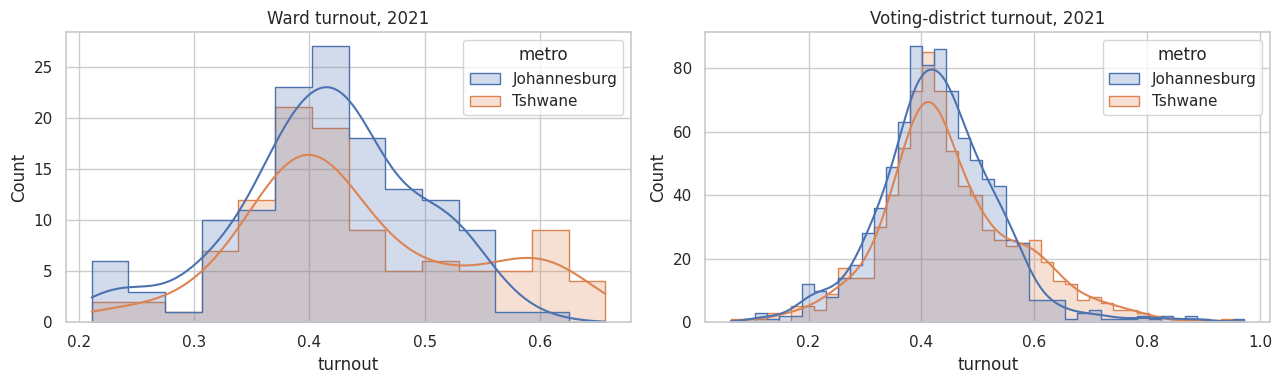

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=wt, x='turnout', hue='metro', kde=True, element='step', ax=ax[0]); ax[0].set_title('Ward turnout, 2021')
sns.histplot(data=vd21, x='turnout', hue='metro', kde=True, element='step', ax=ax[1]); ax[1].set_title('Voting-district turnout, 2021')
plt.tight_layout(); plt.show()

Near-symmetric distributions mean turnout can be modelled directly as a continuous regression target, without transformation.

### 5.3 Does turnout differ by winning party and competitiveness?

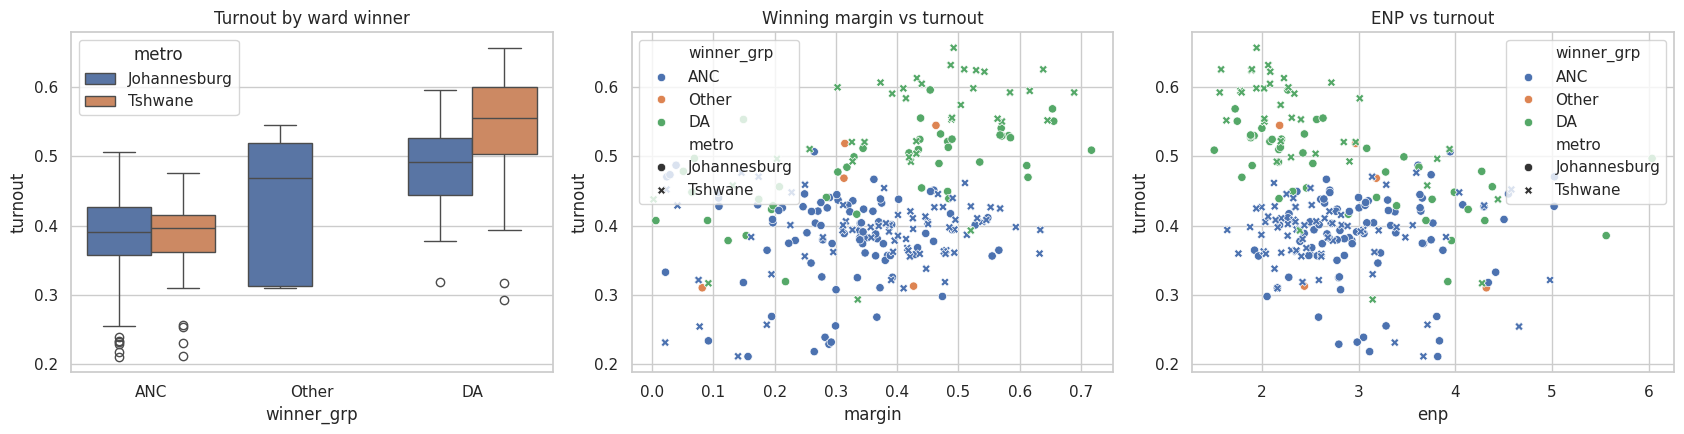

            count  median   mean
winner_grp                      
ANC           157  0.3940 0.3840
DA             80  0.5170 0.5120
Other           5  0.4680 0.4310


In [23]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
sns.boxplot(data=wt, x='winner_grp', y='turnout', hue='metro', ax=ax[0]); ax[0].set_title('Turnout by ward winner')
sns.scatterplot(data=wt, x='margin', y='turnout', hue='winner_grp', style='metro', ax=ax[1]); ax[1].set_title('Winning margin vs turnout')
sns.scatterplot(data=wt, x='enp', y='turnout', hue='winner_grp', style='metro', ax=ax[2]); ax[2].set_title('ENP vs turnout')
plt.tight_layout(); plt.show()
print(wt.groupby('winner_grp').turnout.agg(['count', 'median', 'mean']).round(3))

The party split motivates controlling for **which** party wins before judging whether dominance itself matters (Section 6.2).

### 5.4 Which features move with turnout? (Spearman, FDR-corrected)

,feature,rho,p,n,q_fdr
4,share_EFF,-0.7802,0.0000,242,0.0000
2,share_ANC,-0.6328,0.0000,242,0.0000
6,spoilt_rate,-0.4795,0.0000,242,0.0000
1,enp,-0.2914,0.0000,242,0.0000
5,share_ActionSA,-0.1093,0.0898,242,0.1123
9,retained,-0.0419,0.5167,242,0.5167
8,tent_share,0.0631,0.3286,242,0.3651
7,registered,0.2582,0.0000,242,0.0001
0,margin,0.2984,0.0000,242,0.0000
3,share_DA,0.6057,0.0000,242,0.0000


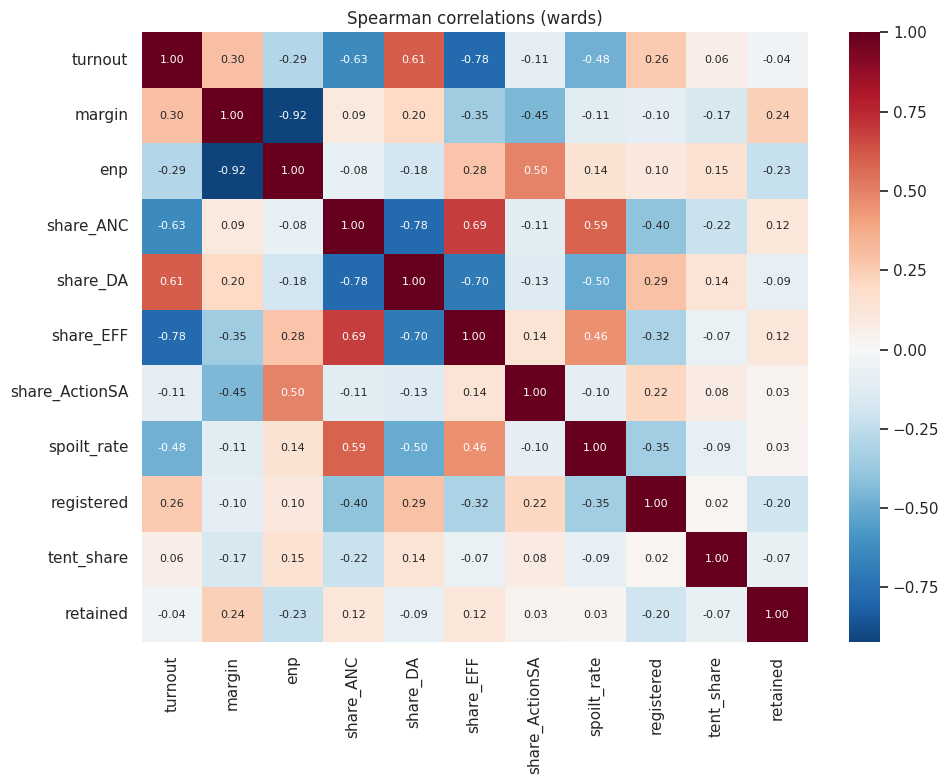

In [24]:
vars_ = [c for c in ['margin', 'enp', 'share_ANC', 'share_DA', 'share_EFF', 'share_ActionSA', 'spoilt_rate', 'registered',
                     'tent_share', 'pct_water_outside_dwelling', 'pct_informal_dwelling', 'pct_refuse_not_weekly',
                     'youth_share_adults', 'retained'] if c in wt and wt[c].notna().sum() > 10]
rows = []
for v in vars_:
    dd = wt[['turnout', v]].dropna()
    r, p = stats.spearmanr(dd.turnout, dd[v]); rows.append({'feature': v, 'rho': r, 'p': p, 'n': len(dd)})
corr = pd.DataFrame(rows); corr['q_fdr'] = multipletests(corr.p, method='fdr_bh')[1]
display(corr.sort_values('rho'))
plt.figure(figsize=(10, 8))
sns.heatmap(wt[['turnout'] + vars_].corr('spearman'), annot=True, fmt='.2f', cmap='RdBu_r', center=0, annot_kws={'size': 8})
plt.title('Spearman correlations (wards)'); plt.tight_layout(); plt.show()

### 5.5 Where are the extreme wards?

In [25]:
show = ['ward_id', 'metro', 'turnout', 'winner', 'margin', 'enp', 'tent_share']
print('Lowest 10 turnout wards');  display(wt.nsmallest(10, 'turnout')[show])
print('Highest 10 turnout wards'); display(wt.nlargest(10, 'turnout')[show])

Lowest 10 turnout wards


,ward_id,metro,turnout,winner,margin,enp,tent_share
122,79800123,Johannesburg,0.2113,ANC,0.1566,3.8191,0.2490
215,79900081,Tshwane,0.2116,ANC,0.1403,3.6707,0.7952
58,79800059,Johannesburg,0.2184,ANC,0.2647,3.1149,0.9773
62,79800063,Johannesburg,0.2291,ANC,0.2887,2.7961,0.0526
214,79900080,Tshwane,0.2315,ANC,0.0213,3.3750,0.0000
63,79800064,Johannesburg,0.2321,ANC,0.2924,2.9860,0.5107
59,79800060,Johannesburg,0.2340,ANC,0.0920,3.8370,0.0000
61,79800062,Johannesburg,0.2390,ANC,0.2823,3.0519,0.3136
192,79900058,Tshwane,0.2546,ANC,0.0776,4.6598,0.0000
109,79800110,Johannesburg,0.2555,ANC,0.2995,3.2846,0.3018


Highest 10 turnout wards


,ward_id,metro,turnout,winner,margin,enp,tent_share
184,79900050,Tshwane,0.6565,DA,0.4923,1.9460,0.0000
179,79900045,Tshwane,0.6315,DA,0.4874,2.0661,0.0774
181,79900047,Tshwane,0.6254,DA,0.5095,1.8972,0.0000
203,79900069,Tshwane,0.6253,DA,0.6384,1.5785,0.0000
178,79900044,Tshwane,0.6241,DA,0.5289,1.8914,0.5105
219,79900085,Tshwane,0.6219,DA,0.5425,2.0876,0.1516
213,79900079,Tshwane,0.6127,DA,0.4322,2.2290,0.2049
225,79900091,Tshwane,0.6063,DA,0.3729,2.7191,0.5632
218,79900084,Tshwane,0.6045,DA,0.4402,2.0848,0.2758
186,79900052,Tshwane,0.5995,DA,0.3027,2.2745,0.0667


In [26]:
if WARD_CENSUS:
    comps = ['pct_water_outside_dwelling', 'pct_informal_dwelling', 'pct_refuse_not_weekly', 'dep_index']
    fig, ax = plt.subplots(1, 4, figsize=(20, 4))
    for a, c in zip(ax, comps):
        sns.regplot(data=wt, x=c, y='turnout', lowess=True, scatter_kws={'s': 12, 'alpha': .5}, ax=a); a.set_title(c)
    plt.tight_layout(); plt.show()
else:
    print('Census deprivation plots skipped (municipality-level files).')

Census deprivation plots skipped (municipality-level files).


---
## 6. Statistical Analysis And Hypothesis Tests

### 6.1 Normality and group differences

In [27]:
sw = stats.shapiro(wt.turnout)
print(f'Shapiro-Wilk ward turnout: W={sw.statistic:.3f}, p={sw.pvalue:.3g}')
j, t = wt.loc[wt.metro == 'Johannesburg', 'turnout'], wt.loc[wt.metro == 'Tshwane', 'turnout']
mw = stats.mannwhitneyu(j, t)
print(f'Metro: median JHB {j.median():.3f} vs TSH {t.median():.3f}; Mann-Whitney p={mw.pvalue:.3g}, '
      f'rank-biserial={1 - 2 * mw.statistic / (len(j) * len(t)):.3f}')
kw = stats.kruskal(*[g.turnout for _, g in wt.groupby('winner_grp')])
print(f'Winner group: Kruskal-Wallis H={kw.statistic:.1f}, p={kw.pvalue:.3g}')
RESULTS.update({'metro_p': float(mw.pvalue), 'party_kw_p': float(kw.pvalue),
                'median_turnout_by_winner': wt.groupby('winner_grp').turnout.median().round(4).to_dict()})

Shapiro-Wilk ward turnout: W=0.980, p=0.00155
Metro: median JHB 0.421 vs TSH 0.411; Mann-Whitney p=0.225, rank-biserial=0.091
Winner group: Kruskal-Wallis H=107.5, p=4.61e-24


### 6.2 Cross-Sectional Analysis: Political Dominance and Turnout

#### Model Specifications
* **M1 (Baseline):** $\text{Turnout}_z \sim \text{Margin}_z + \text{Metro}$
* **M2 (Party Fixed Effects):** $\text{Turnout}_z \sim \text{Margin}_z + \text{Winner\_Group} + \text{Metro}$
* **M3 (Party Interaction):** $\text{Turnout}_z \sim \text{Margin}_z \times \text{Winner\_Group} + \text{Metro}$
* **M4 (Fragmentation Alternative):** $\text{Turnout}_z \sim \text{ENP}_z + \text{Winner\_Group} + \text{Metro}$

All continuous predictors and outcome variables are z-score standardized prior to estimation. Models are fitted using HC3 heteroskedasticity-robust standard errors.

,model,term,beta_SD,ci_low,ci_high,p,R2
0,M1 raw,margin_z,0.3475,0.2196,0.4753,0.0000,0.1352
1,M2 within party,margin_z,0.2237,0.1147,0.3326,0.0001,0.5156
2,M4 ENP within party,enp_z,-0.2050,-0.3155,-0.0944,0.0003,0.5084
3,M3 ANC wards,margin_z,0.0456,-0.1144,0.2056,0.5767,0.5489
4,M3 DA wards,margin_z + interaction,0.4090,NaN,NaN,0.0003,0.5489


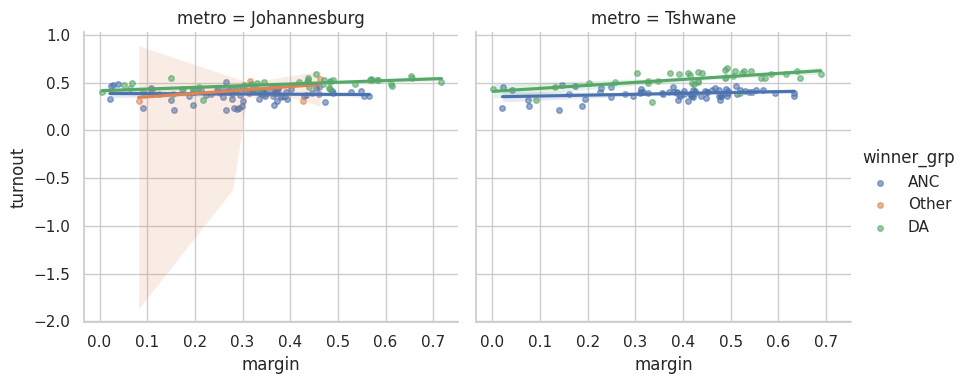

In [28]:
z = lambda s: (s - s.mean()) / s.std()
W = wt.assign(turnout_z=z(wt.turnout), margin_z=z(wt.margin), enp_z=z(wt.enp))
m1 = smf.ols('turnout_z ~ margin_z + C(metro)', W).fit(cov_type='HC3')
m2 = smf.ols('turnout_z ~ margin_z + C(winner_grp) + C(metro)', W).fit(cov_type='HC3')
m3 = smf.ols('turnout_z ~ margin_z * C(winner_grp) + C(metro)', W).fit(cov_type='HC3')
m4 = smf.ols('turnout_z ~ enp_z + C(winner_grp) + C(metro)', W).fit(cov_type='HC3')
tab = []
for nm, m, k in [('M1 raw', m1, 'margin_z'), ('M2 within party', m2, 'margin_z'), ('M4 ENP within party', m4, 'enp_z'),
                 ('M3 ANC wards', m3, 'margin_z')]:
    ci = m.conf_int().loc[k]
    tab.append({'model': nm, 'term': k, 'beta_SD': m.params[k], 'ci_low': ci[0], 'ci_high': ci[1], 'p': m.pvalues[k], 'R2': m.rsquared})
da_b = m3.params['margin_z'] + m3.params['margin_z:C(winner_grp)[T.DA]']
tab.append({'model': 'M3 DA wards', 'term': 'margin_z + interaction', 'beta_SD': da_b,
            'p': m3.pvalues['margin_z:C(winner_grp)[T.DA]'], 'R2': m3.rsquared})
h2x = pd.DataFrame(tab); display(h2x.round(4))
RESULTS['H2_cross'] = {'m1': float(m1.params['margin_z']), 'm2': float(m2.params['margin_z']), 'm2_p': float(m2.pvalues['margin_z']),
                       'anc': float(m3.params['margin_z']), 'anc_p': float(m3.pvalues['margin_z']), 'da': float(da_b)}
sns.lmplot(data=wt, x='margin', y='turnout', hue='winner_grp', col='metro', height=4, aspect=1.1, scatter_kws={'s': 16, 'alpha': .6})
plt.show()

*Caution:* these are associations. When one group of voters stays home, the margin itself changes, so causality can run both ways.

### 6.3 Longitudinal Analysis: Electoral Disengagement vs. Defection (2016–2021)

#### Analytical Approach
* **Non-Parametric Group Comparison:** Evaluate differential turnout changes ($\Delta \text{Turnout}$) between retained wards and wards that changed political control.
* **Controlled Regression Specification:**
  $$\text{Turnout}_{i, 2021} = \beta_0 + \beta_1 \text{Retained}_i + \beta_2 \text{Turnout}_{i, 2016} + \gamma \text{Metro}_i + \varepsilon_i$$
* **Decomposition Mechanism:** Compare relative declines in turnout against incumbent vote share shifts within retained wards to isolate voter apathy from party switching.


Retained 231 | flipped 11
Median d_turnout retained -0.144 vs flipped -0.155; one-sided p=0.589
Controlled: retained beta = -0.05 pp (p=0.963)
Retained wards: mean d_turnout -0.146, mean d_incumbent_share -0.131


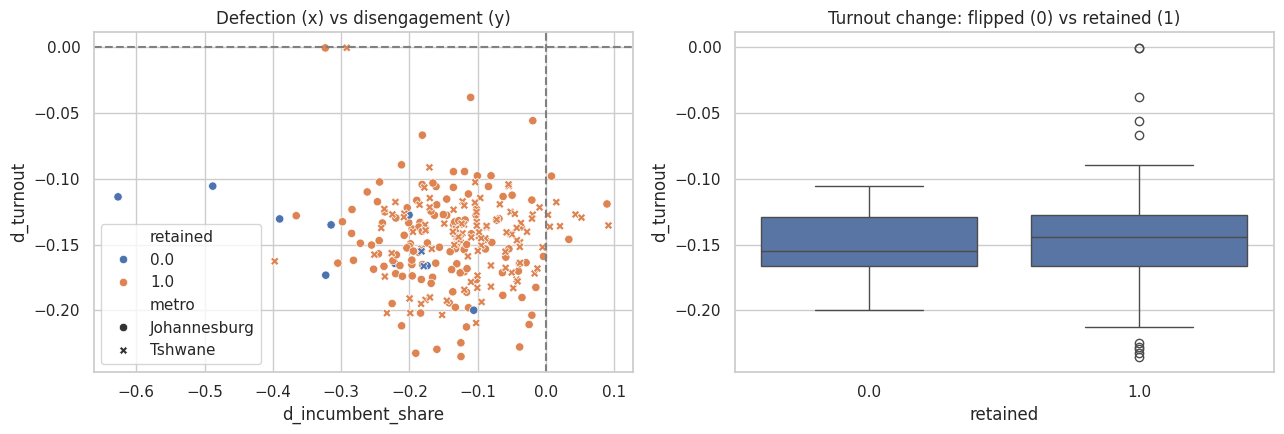

In [29]:
if HAS_2016:
    d2 = wt.dropna(subset=['retained', 'd_turnout'])
    ret, flip = d2.loc[d2.retained == 1, 'd_turnout'], d2.loc[d2.retained == 0, 'd_turnout']
    print(f'Retained {len(ret)} | flipped {len(flip)}')
    if len(flip) >= 5:
        u = stats.mannwhitneyu(ret, flip, alternative='less')
        print(f'Median d_turnout retained {ret.median():+.3f} vs flipped {flip.median():+.3f}; one-sided p={u.pvalue:.3g}')
    ctrl = ' + dep_index' if WARD_CENSUS else ''
    mt = smf.ols(f'turnout ~ retained + turnout_2016 + C(metro){ctrl}', d2).fit(cov_type='HC3')
    print(f"Controlled: retained beta = {mt.params['retained']*100:+.2f} pp (p={mt.pvalues['retained']:.3g})")
    r_ = d2[d2.retained == 1]
    print(f"Retained wards: mean d_turnout {r_.d_turnout.mean():+.3f}, mean d_incumbent_share {r_.d_incumbent_share.mean():+.3f}")
    RESULTS['H2_time'] = {'beta_pp': float(mt.params['retained'] * 100), 'p': float(mt.pvalues['retained']),
                          'dturn': float(r_.d_turnout.mean()), 'dshare': float(r_.d_incumbent_share.mean())}
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.scatterplot(data=d2, x='d_incumbent_share', y='d_turnout', hue='retained', style='metro', ax=ax[0])
    ax[0].axhline(0, c='grey', ls='--'); ax[0].axvline(0, c='grey', ls='--'); ax[0].set_title('Defection (x) vs disengagement (y)')
    sns.boxplot(data=d2, x='retained', y='d_turnout', ax=ax[1]); ax[1].set_title('Turnout change: flipped (0) vs retained (1)')
    plt.tight_layout(); plt.show()
else:
    print('Skipped — needs the 2016 file.')

### 6.4 Sub-Ward Infrastructure Analysis: Temporary Stations and Turnout

* **Ward Fixed-Effects Model:** Controls for unobserved ward-level heterogeneity (local councillor effects, general political alignment, and socio-economic baseline) across voting districts (VDs):

$$\text{Turnout}_{ij} = \alpha_j + \beta_1 \text{Tent}_{ij} + \beta_2 \ln(\text{Registered}_{ij}) + \varepsilon_{ij}$$

where $i$ indexes the voting district and $j$ indexes the ward. Standard errors are clustered at the ward level.

,count,median,mean
station_type,,,
Church,194,0.4270,0.4440
Hall/Centre,208,0.4130,0.4190
Other,230,0.4510,0.4560
School,853,0.4280,0.4380
Tent,155,0.4450,0.4590


Wards with both tent and building VDs: 99
Within-ward tent effect: -1.00 pp, 95% CI [-3.12, +1.13], p=0.358


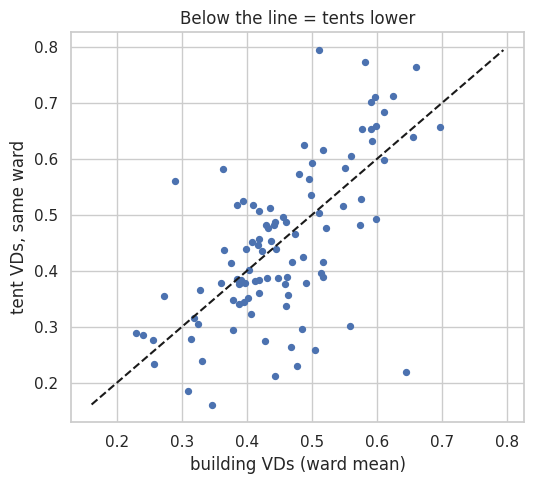

In [30]:
display(vd21.groupby('station_type').turnout.agg(['count', 'median', 'mean']).round(3))
fe = smf.ols('turnout ~ tent + log_registered + C(ward_id)', vd21).fit(cov_type='cluster', cov_kwds={'groups': vd21['ward_id']})
b, ci = fe.params['tent'], fe.conf_int().loc['tent']
mixed = vd21.groupby('ward_id').tent.transform(lambda s: 0 < s.mean() < 1)
print(f'Wards with both tent and building VDs: {vd21.loc[mixed, "ward_id"].nunique()}')
print(f'Within-ward tent effect: {b*100:+.2f} pp, 95% CI [{ci[0]*100:+.2f}, {ci[1]*100:+.2f}], p={fe.pvalues["tent"]:.3g}')
RESULTS['tent'] = {'pp': float(b * 100), 'lo': float(ci[0] * 100), 'hi': float(ci[1] * 100), 'p': float(fe.pvalues['tent'])}
mm = vd21[mixed].groupby(['ward_id', 'tent']).turnout.mean().unstack()
plt.figure(figsize=(5.5, 5)); plt.scatter(mm[0], mm[1], s=18)
lim = [mm.min().min(), mm.max().max()]; plt.plot(lim, lim, 'k--')
plt.xlabel('building VDs (ward mean)'); plt.ylabel('tent VDs, same ward'); plt.title('Below the line = tents lower')
plt.tight_layout(); plt.show()

### 6.5 Socio-Economic Deprivation Analysis (Census 2022 Integration)

#### Model Specifications
* **Standardised OLS Estimation:** Evaluates ward-level voter turnout against individual Census deprivation components alongside the composite deprivation index.
* **Control Variables:** Incorporates winning party fixed effects and metro-level controls to measure the marginal impact of structural deprivation independent of political alignment.

$$\text{Turnout}_z = \beta_0 + \beta_1 \text{Deprivation}_z + \boldsymbol{\gamma} \mathbf{X} + \varepsilon$$

where continuous variables are z-score standardized and $\mathbf{X}$ vector includes political party and metropolitan control indicators.

In [31]:
if WARD_CENSUS:
    comps = ['pct_water_outside_dwelling', 'pct_informal_dwelling', 'pct_refuse_not_weekly']
    D = wt.dropna(subset=comps).copy()
    for c in comps + ['turnout', 'dep_index', 'youth_share_adults']:
        D[c + '_z'] = z(D[c])
    mA = smf.ols('turnout_z ~ dep_index_z + C(metro)', D).fit(cov_type='HC3')
    mB = smf.ols('turnout_z ~ dep_index_z + C(winner_grp) + C(metro)', D).fit(cov_type='HC3')
    mC = smf.ols('turnout_z ~ ' + ' + '.join(c + '_z' for c in comps) + ' + youth_share_adults_z + C(winner_grp) + C(metro)', D).fit(cov_type='HC3')
    print(f"Deprivation index: raw beta={mA.params['dep_index_z']:+.3f} (p={mA.pvalues['dep_index_z']:.3g}); "
          f"within party beta={mB.params['dep_index_z']:+.3f} (p={mB.pvalues['dep_index_z']:.3g})")
    display(pd.DataFrame({'beta_SD': mC.params, 'p': mC.pvalues}).round(4))
    RESULTS['H1'] = {'raw': float(mA.params['dep_index_z']), 'raw_p': float(mA.pvalues['dep_index_z']),
                     'within': float(mB.params['dep_index_z']), 'within_p': float(mB.pvalues['dep_index_z'])}
    r, p = stats.spearmanr(D.tent_share, D.pct_informal_dwelling)
    print(f'Proxy validation: Spearman(tent_share, Census % informal) = {r:.3f} (p={p:.3g})')
else:
    print('Skipped — census files are municipality-level. Re-export at Ward level to enable.')

Skipped — census files are municipality-level. Re-export at Ward level to enable.


### 7. Model Selection, Training, Testing And Evaluation

#### 7.1 Methodological Framework And Validation Strategy

* **Task Definition:** Continuous OLS and non-linear regression modeling predicting voter turnout rates across individual Voting Districts (VDs, $n = 1{,}640$).
* **Cross-Validation Scheme:** GroupKFold stratified at the ward level ($n = 242$) to prevent spatial data leakage between contiguous voting districts.
* **Model Candidates:** Ordinary Least Squares (baseline), Ridge Regression (multicollinearity regularization), Random Forest, Gradient Boosting, and XGBoost.
* **Model Selection Criteria:**
  * **Parsimony Rule:** Select the simplest model within 1 standard error of minimum mean squared error (1-SE rule).
  * **Multicollinearity Constraint:** Exclude linear specifications exhibiting Variance Inflation Factor (VIF) $> 10$.

In [32]:
M = vd21.merge(wt.drop(columns=['metro', 'registered', 'valid', 'spoilt', 'turnout', 'spoilt_rate', 'n_vd'], errors='ignore'),
               on='ward_id', how='left')
NUM = ['log_registered', 'margin', 'enp', 'share_ANC', 'share_DA', 'share_EFF', 'share_ActionSA']
if WARD_CENSUS:
    NUM += ['pct_water_outside_dwelling', 'pct_informal_dwelling', 'pct_refuse_not_weekly', 'youth_share_adults']
CAT = ['station_type', 'winner_grp', 'metro']
X, y, groups = M[NUM + CAT], M['turnout'], M['ward_id']

def make_prep(num, cat):
    return ColumnTransformer([('n', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), num),
                              ('c', OneHotEncoder(handle_unknown='ignore'), cat)])
P = lambda m, num=NUM, cat=CAT: Pipeline([('prep', make_prep(num, cat)), ('m', m)])
MODELS = {
    'Baseline (mean)':   P(DummyRegressor()),
    'OLS':               P(LinearRegression()),
    'Ridge':             P(RidgeCV(alphas=np.logspace(-3, 3, 30))),
    'Random Forest':     P(RandomForestRegressor(400, min_samples_leaf=10, max_features=0.5, random_state=RNG, n_jobs=-1)),
    'Gradient Boosting': P(GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=RNG)),
}
if HAS_XGB:
    MODELS['XGBoost'] = P(XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=3, subsample=0.8, colsample_bytree=0.8,
                                       min_child_weight=10, random_state=RNG, n_jobs=-1, verbosity=0))
cv = GroupKFold(n_splits=5)
print(f'n = {len(y)} VDs in {groups.nunique()} wards | features: {NUM + CAT}')

n = 1640 VDs in 242 wards | features: ['log_registered', 'margin', 'enp', 'share_ANC', 'share_DA', 'share_EFF', 'share_ActionSA', 'station_type', 'winner_grp', 'metro']


### 7.2 Train and test every candidate under ward-grouped cross-validation

,MAE_pp,MAE_sd,R2,R2_sd,MAE_se
model,,,,,
Baseline (mean),8.5722,0.8635,-0.0004,0.0005,0.3862
OLS,6.3255,0.5580,0.3652,0.0370,0.2495
Ridge,6.3250,0.5639,0.3651,0.0379,0.2522
Random Forest,6.2778,0.5973,0.3731,0.0451,0.2671
Gradient Boosting,6.5457,0.5771,0.3078,0.0674,0.2581
XGBoost,6.5038,0.5534,0.3478,0.0518,0.2475


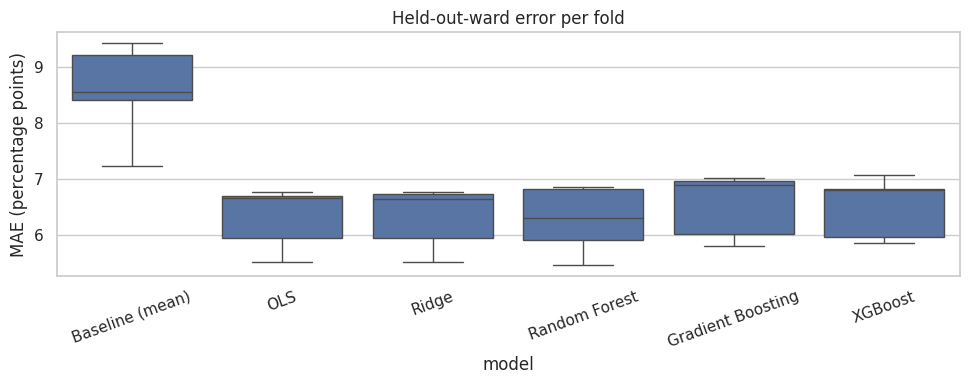

In [33]:
rows, oof = [], {}
for name, est in MODELS.items():
    pred = np.zeros(len(y))
    for k, (tr, te) in enumerate(cv.split(X, y, groups)):
        m = clone(est).fit(X.iloc[tr], y.iloc[tr]); p = m.predict(X.iloc[te]); pred[te] = p
        rows.append({'model': name, 'fold': k, 'MAE_pp': 100 * mean_absolute_error(y.iloc[te], p), 'R2': r2_score(y.iloc[te], p)})
    oof[name] = pred
folds = pd.DataFrame(rows)
summ = folds.groupby('model').agg(MAE_pp=('MAE_pp', 'mean'), MAE_sd=('MAE_pp', 'std'), R2=('R2', 'mean'), R2_sd=('R2', 'std')).loc[list(MODELS)]
summ['MAE_se'] = summ.MAE_sd / np.sqrt(cv.get_n_splits())
display(summ.round(4))
plt.figure(figsize=(10, 4)); sns.boxplot(data=folds, x='model', y='MAE_pp', order=list(MODELS))
plt.xticks(rotation=20); plt.ylabel('MAE (percentage points)'); plt.title('Held-out-ward error per fold'); plt.tight_layout(); plt.show()

### 7.3 Apply the selection rule

In [34]:
s = summ.drop('Baseline (mean)')
best = s.MAE_pp.idxmin(); thr = s.loc[best, 'MAE_pp'] + s.loc[best, 'MAE_se']
eligible = [m for m in s.index if s.loc[m, 'MAE_pp'] <= thr]
Xn = M[NUM].fillna(M[NUM].median()); Xn = (Xn - Xn.mean()) / Xn.std(); Xn.insert(0, 'const', 1.0)
vif = pd.Series([variance_inflation_factor(Xn.values, i) for i in range(1, Xn.shape[1])], index=NUM)
print('VIF:', vif.round(1).to_dict())
if vif.max() > 10 and 'OLS' in eligible and len(eligible) > 1:
    eligible.remove('OLS'); print(f'Max VIF {vif.max():.1f} > 10 -> OLS excluded (unstable coefficients).')
CHOSEN = eligible[0]
base = summ.loc['Baseline (mean)', 'MAE_pp']
print(f'Lowest MAE: {best} ({s.loc[best,"MAE_pp"]:.2f} ± {s.loc[best,"MAE_se"]:.2f} pp) -> threshold {thr:.2f}; eligible {eligible}')
print(f'CHOSEN: {CHOSEN} | MAE {s.loc[CHOSEN,"MAE_pp"]:.2f} pp | R2 {s.loc[CHOSEN,"R2"]:.3f} | '
      f'{1 - s.loc[CHOSEN,"MAE_pp"]/base:.0%} lower error than the baseline ({base:.2f} pp)')
RESULTS['model'] = {'chosen': CHOSEN, 'best': best, 'mae_pp': float(s.loc[CHOSEN, 'MAE_pp']), 'r2': float(s.loc[CHOSEN, 'R2']),
                    'baseline_mae_pp': float(base), 'table': summ[['MAE_pp', 'R2']].round(4).to_dict('index')}

VIF: {'log_registered': 1.1, 'margin': 5.9, 'enp': 5.3, 'share_ANC': 11.2, 'share_DA': 10.9, 'share_EFF': 3.0, 'share_ActionSA': 1.3}
Max VIF 11.2 > 10 -> OLS excluded (unstable coefficients).
Lowest MAE: Random Forest (6.28 ± 0.27 pp) -> threshold 6.54; eligible ['Ridge', 'Random Forest', 'XGBoost']
CHOSEN: Ridge | MAE 6.32 pp | R2 0.365 | 26% lower error than the baseline (8.57 pp)


#### Model Selection Rationale

* **Model Selection:** Ridge Regression is selected under the parsimony (1-SE) criterion. Given sample variance across cross-validation folds ($n \approx 1{,}640$), performance differences among top-performing estimators fall within sampling error.
* **Interpretability Advantage:** Ridge estimation provides direct linear coefficient interpretations for policy analysis while controlling for feature collinearity.

### 7.4 Classification Analysis: Low-Turnout Voting Districts

* **Target Variable:** Binary indicator identifying voting districts within the bottom tercile of voter turnout ($\le 33\text{rd}$ percentile).
* **Model Specifications:**
  * **Baseline:** Stratified dummy classifier.
  * **Logistic Regression:** L2-regularized logistic model with balanced class weights.
  * **Random Forest:** Ensemble classifier (400 estimators, balanced class weights).

In [35]:
y_cls = (y <= y.quantile(1 / 3)).astype(int)
CLS = {'Baseline': P(DummyClassifier()),
       'Logistic (L2)': P(LogisticRegression(max_iter=3000, class_weight='balanced')),
       'Random Forest': P(RandomForestClassifier(400, min_samples_leaf=10, max_features=0.5, class_weight='balanced', random_state=RNG, n_jobs=-1))}
out = []
for name, est in CLS.items():
    for tr, te in cv.split(X, y_cls, groups):
        pr = clone(est).fit(X.iloc[tr], y_cls.iloc[tr]).predict_proba(X.iloc[te])[:, 1]
        out.append({'model': name, 'AUC': roc_auc_score(y_cls.iloc[te], pr), 'BalAcc': balanced_accuracy_score(y_cls.iloc[te], pr >= .5)})
cls = pd.DataFrame(out).groupby('model').agg(['mean', 'std']); display(cls.round(4))
reg_auc = np.mean([roc_auc_score(y_cls.iloc[te], -oof[CHOSEN][te]) for _, te in cv.split(X, y_cls, groups)])
print(f'{CHOSEN} predictions used as a risk ranking: AUC = {reg_auc:.3f}')
RESULTS['cls'] = {'best_auc': float(cls[('AUC', 'mean')].drop('Baseline').max()), 'reg_auc': float(reg_auc)}

AUC        BalAcc       
                mean    std   mean    std
model                                    
Baseline      0.5000 0.0000 0.5000 0.0000
Logistic (L2) 0.7464 0.0273 0.6660 0.0154
Random Forest 0.7693 0.0312 0.6841 0.0296

Ridge predictions used as a risk ranking: AUC = 0.757


* **Model Unification:** Regression-based risk rankings yield ROC-AUC performance ($\text{AUC} = 0.757$) comparable to dedicated classifiers, permitting a unified regression architecture across continuous and categorical tasks.

### 7.5 Feature Importance and Diagnostic Analysis

* **Permutation Importance:** Evaluated on the selected Ridge model using mean absolute error ($\Delta\text{MAE}$ in percentage points across 15 iterations).
* **Out-of-Fold Diagnostics:** Scatter plot comparison of predicted vs. actual turnout across held-out wards to assess linear alignment and residual variance.


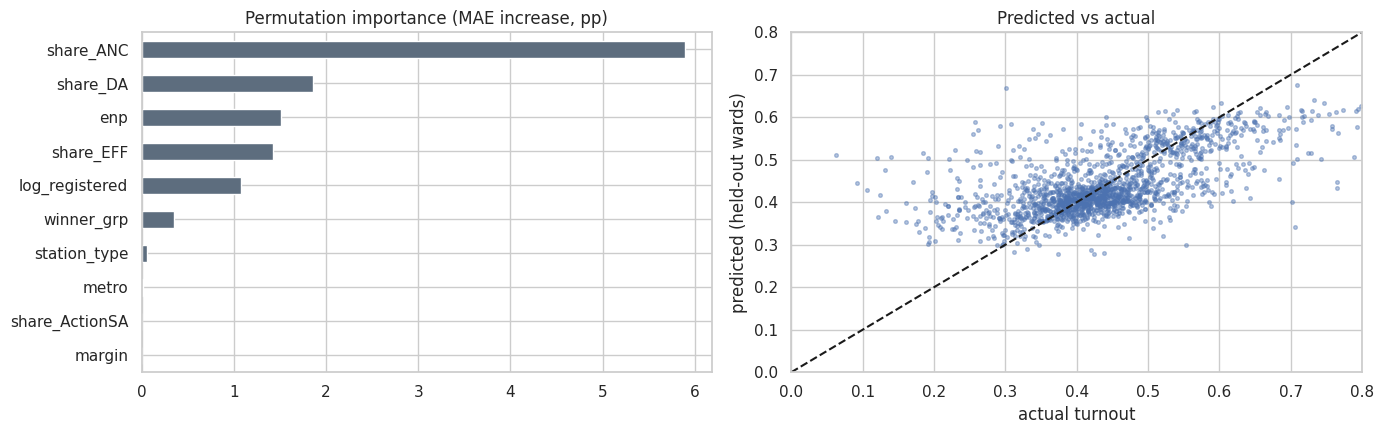

,pp per SD (numeric) / vs other levels (categorical)
n__share_ANC,-8.8200
c__winner_grp_Other,-7.8800
n__share_DA,-4.3700
n__enp,-3.6800
n__share_EFF,-3.6300
n__log_registered,-3.2800
c__station_type_Hall/Centre,-0.7700
c__station_type_Tent,-0.3900
c__station_type_Other,-0.3700
c__metro_Johannesburg,-0.3200


In [36]:
final = clone(MODELS[CHOSEN]).fit(X, y)
pi = permutation_importance(final, X, y, n_repeats=15, random_state=RNG, scoring='neg_mean_absolute_error')
imp = pd.Series(pi.importances_mean * 100, index=X.columns).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
imp.plot.barh(ax=ax[0], color='#5d6d7e'); ax[0].set_title('Permutation importance (MAE increase, pp)')
ax[1].scatter(y, oof[CHOSEN], s=7, alpha=.4); ax[1].plot([0, 1], [0, 1], 'k--'); ax[1].set_xlim(0, .8); ax[1].set_ylim(0, .8)
ax[1].set_xlabel('actual turnout'); ax[1].set_ylabel('predicted (held-out wards)'); ax[1].set_title('Predicted vs actual')
plt.tight_layout(); plt.show()
if hasattr(final.named_steps['m'], 'coef_'):
    coefs = pd.Series(final.named_steps['m'].coef_, index=final.named_steps['prep'].get_feature_names_out())
    display((coefs * 100).round(2).sort_values().to_frame('pp per SD (numeric) / vs other levels (categorical)'))
RESULTS['top_features'] = imp.sort_values(ascending=False).index[:4].tolist()

### 7.6 Mobilisation Gap Analysis

The mobilization gap measures the divergence between observed voter turnout and model predictions derived from out-of-fold cross-validation:

$$\Delta y_i = y_i - \hat{y}_i$$

where $y_i$ represents observed turnout in voting district $i$, and $\hat{y}_i$ denotes the predicted turnout. Negative residuals ($\Delta y_i < 0$) highlight districts that underperform relative to their structural baseline.


In [37]:
vd21['pred_turnout'] = oof[CHOSEN]
vd21['gap_pp'] = (vd21['turnout'] - vd21['pred_turnout']) * 100
vd21['low_turnout_flag'] = (vd21['turnout'] <= vd21['turnout'].quantile(1 / 3)).astype(int)
ward_gap = vd21.groupby('ward_id').apply(lambda g: np.average(g.gap_pp, weights=g.registered)).rename('ward_gap_pp')
wt = wt.merge(ward_gap, left_on='ward_id', right_index=True, how='left')
print('VDs furthest below expectation:')
display(vd21.nsmallest(10, 'gap_pp')[['VotingDistrict', 'ward_id', 'metro', 'station', 'turnout', 'pred_turnout', 'gap_pp']].round(3))
print('Wards furthest below expectation (registered-weighted):')
display(wt.nsmallest(10, 'ward_gap_pp')[['ward_id', 'metro', 'winner', 'turnout', 'ward_gap_pp']].round(3))

VDs furthest below expectation:


,VotingDistrict,ward_id,metro,station,turnout,pred_turnout,gap_pp
1380,33050067,79900100,Tshwane,CHRIS HANI FLATS,0.0620,0.5120,-44.9480
555,32862449,79800006,Johannesburg,JOHWETO COMBINED SCHOOL,0.1200,0.5030,-38.2950
1353,32980518,79900066,Tshwane,TENT - OPEN SPACE NEXT TO AIRSCHOOL SPORTS GROUND,0.3010,0.6690,-36.7840
1499,54510162,79900104,Tshwane,PRINCE OF PEACE WORSHIP CENTRE,0.1390,0.5060,-36.6570
214,32850389,79800118,Johannesburg,KENSINGTON RIDGE PRIMARY SCHOOL,0.0930,0.4450,-35.2750
891,32950289,79900059,Tshwane,LAERSKOOL PARATUS,0.1310,0.4760,-34.4990
1550,86663548,79900095,Tshwane,BOKAMOSO LEARNING ACADEMY,0.1840,0.5160,-33.1830
0,32840018,79800094,Johannesburg,TENT @ RIVERSANDS INCUBATION HUB,0.2580,0.5890,-33.1340
1197,32960134,79900036,Tshwane,TSHWANE NORTH COLLEGE,0.1060,0.4280,-32.2800
1390,33110053,79900105,Tshwane,TENT -EZEMVELO NATURE RESERVE,0.1910,0.5040,-31.2830


Wards furthest below expectation (registered-weighted):


,ward_id,metro,winner,turnout,ward_gap_pp
193,79900059,Tshwane,DA,0.2940,-17.2240
64,79800065,Johannesburg,IFP,0.3130,-16.4380
190,79900056,Tshwane,DA,0.3930,-14.7830
122,79800123,Johannesburg,ANC,0.2110,-14.2160
59,79800060,Johannesburg,ANC,0.2340,-13.2550
62,79800063,Johannesburg,ANC,0.2290,-13.1550
172,79900038,Tshwane,ANC,0.2570,-12.8140
63,79800064,Johannesburg,ANC,0.2320,-12.4780
215,79900081,Tshwane,ANC,0.2120,-11.8810
58,79800059,Johannesburg,ANC,0.2180,-11.5340


### 7.7 Predictive Forecasting Model for 2026

#### Methodological Framework
* **Lagged Feature Architecture:** Models election turnout at time $t$ using historical covariates from election $t-1$ combined with static structural indicators to prevent target leakage.
  * **Model Estimation ($t = 2021$):** Fitted on 2021 turnout outcomes using lagged 2016 electoral variables and structural features.
  * **Model Projection ($t = 2026$):** Forecasts 2026 turnout outcomes using lagged 2021 electoral variables and structural features.
* **Validation Strategy:** Spatial block cross-validation grouped across 8 consecutive ward units to preserve spatial autocorrelation boundaries.


In [38]:
if HAS_2016:
    LAG = ['turnout', 'margin', 'enp', 'share_ANC', 'share_DA', 'spoilt_rate']
    STRUCT = ['tent_share'] + (['pct_water_outside_dwelling', 'pct_informal_dwelling', 'pct_refuse_not_weekly', 'youth_share_adults'] if WARD_CENSUS else [])
    def frame(lag_sfx):
        F = wt[STRUCT].copy()
        for v in LAG:
            F['lag_' + v] = wt[v + lag_sfx]
        F['lag_winner'] = wt['winner_grp' + lag_sfx] if 'winner_grp' + lag_sfx in wt else wt['winner_grp']
        F['metro'] = wt['metro']
        return F
    FNUM = STRUCT + ['lag_' + v for v in LAG]; FCAT = ['lag_winner', 'metro']
    Xf, yf = frame('_2016'), wt['turnout']
    blocks = wt['metro'].str[:3] + '_' + (wt['ward_num'] // 8).astype(str)
    FM = {'Baseline (mean)': P(DummyRegressor(), FNUM, FCAT), 'Ridge': P(RidgeCV(alphas=np.logspace(-3, 3, 30)), FNUM, FCAT),
          'Random Forest': P(RandomForestRegressor(400, min_samples_leaf=5, max_features=0.5, random_state=RNG, n_jobs=-1), FNUM, FCAT)}
    for k in FM:   # impute missing lags (VDs new in 2021) inside the pipeline
        FM[k].steps[0] = ('prep', ColumnTransformer([('n', Pipeline([('imp', SimpleImputer(strategy='median', add_indicator=True)),
                                                                     ('sc', StandardScaler())]), FNUM),
                                                     ('c', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                                                                     ('oh', OneHotEncoder(handle_unknown='ignore'))]), FCAT)]))
    fr, foof = [], {}
    for name, est in FM.items():
        pr = np.zeros(len(yf))
        for tr, te in GroupKFold(5).split(Xf, yf, blocks):
            pr[te] = clone(est).fit(Xf.iloc[tr], yf.iloc[tr]).predict(Xf.iloc[te])
        foof[name] = pr
        fr.append({'model': name, 'MAE_pp': 100 * mean_absolute_error(yf, pr), 'R2': r2_score(yf, pr)})
    fsum = pd.DataFrame(fr).set_index('model'); display(fsum.round(4))
    FCHOSEN = 'Ridge' if fsum.loc['Ridge', 'MAE_pp'] <= fsum.loc['Random Forest', 'MAE_pp'] * 1.03 else 'Random Forest'
    fmodel = clone(FM[FCHOSEN]).fit(Xf, yf)
    res = yf - foof[FCHOSEN]; qlo, qhi = np.percentile(res, [5, 95])
    wt['forecast_2026'] = fmodel.predict(frame(''))
    wt['forecast_lo'] = (wt.forecast_2026 + qlo).clip(0, 1); wt['forecast_hi'] = (wt.forecast_2026 + qhi).clip(0, 1)
    print(f'Forecast model: {FCHOSEN}; 90% interval width about {100*(qhi-qlo):.1f} pp')
    display(wt.nsmallest(10, 'forecast_2026')[['ward_id', 'metro', 'turnout', 'forecast_2026', 'forecast_lo', 'forecast_hi']].round(3))
    RESULTS['forecast'] = {'model': FCHOSEN, 'mae_pp': float(fsum.loc[FCHOSEN, 'MAE_pp']), 'r2': float(fsum.loc[FCHOSEN, 'R2'])}
    joblib.dump(fmodel, os.path.join(OUT_DIR, 'forecast_model_2026.joblib'))
else:
    print('Skipped — the 2026 forecast needs 2016 results for lagged features.')

,MAE_pp,R2
model,,
Baseline (mean),6.9327,-0.0183
Ridge,2.4416,0.8765
Random Forest,2.6756,0.8511


Forecast model: Ridge; 90% interval width about 9.2 pp


,ward_id,metro,turnout,forecast_2026,forecast_lo,forecast_hi
215,79900081,Tshwane,0.2120,0.1190,0.0720,0.1640
122,79800123,Johannesburg,0.2110,0.1220,0.0750,0.1670
58,79800059,Johannesburg,0.2180,0.1230,0.0760,0.1680
59,79800060,Johannesburg,0.2340,0.1430,0.0960,0.1880
63,79800064,Johannesburg,0.2320,0.1440,0.0970,0.1890
214,79900080,Tshwane,0.2310,0.1480,0.1010,0.1930
62,79800063,Johannesburg,0.2290,0.1490,0.1030,0.1950
61,79800062,Johannesburg,0.2390,0.1510,0.1040,0.1960
192,79900058,Tshwane,0.2550,0.1570,0.1100,0.2020
109,79800110,Johannesburg,0.2550,0.1650,0.1180,0.2100


---
## 8. Interpretation Against the Problem Statement

In [39]:
R = RESULTS
print('=' * 88)
print(f"Coverage: {len(wt)} wards, {len(vd21)} voting districts. Overall turnout: " +
      ', '.join(f'{k} {v:.1%}' for k, v in R['turnout_overall'].items()) + f" (metro difference p={R['metro_p']:.2g}).")
print(f"Party divide: median ward turnout " + ', '.join(f'{k} {v:.1%}' for k, v in R['median_turnout_by_winner'].items()) +
      f" (Kruskal-Wallis p={R['party_kw_p']:.2g}).")
h = R['H2_cross']
print(f"\nH2 cross-sectional: margin effect raw {h['m1']:+.2f} SD; within same winner {h['m2']:+.2f} SD (p={h['m2_p']:.2g}); "
      f"ANC wards {h['anc']:+.2f} SD (p={h['anc_p']:.2g}); DA wards {h['da']:+.2f} SD.")
print('  -> ' + ('NOT supported: dominance goes with HIGHER turnout, driven by DA strongholds; no effect in ANC wards.'
               if h['m2'] > 0 and h['m2_p'] < .05 else
               'SUPPORTED: dominance goes with lower turnout within the same winning party.' if h['m2'] < 0 and h['m2_p'] < .05 else
               'No significant dominance effect within the same winning party.'))
if 'H2_time' in R:
    t_ = R['H2_time']
    print(f"H2 over time: retained ward effect {t_['beta_pp']:+.2f} pp (p={t_['p']:.2g}); retained wards: turnout change "
          f"{t_['dturn']:+.3f} vs incumbent-share change {t_['dshare']:+.3f} -> " +
          ('disengagement > defection' if abs(t_['dturn']) > abs(t_['dshare']) else 'defection >= disengagement'))
tn = R['tent']
print(f"\nH1 proxy: tent-served VDs {tn['pp']:+.1f} pp vs buildings in the same ward (95% CI [{tn['lo']:+.1f}, {tn['hi']:+.1f}], p={tn['p']:.2g}) -> " +
      ('significant' if tn['p'] < .05 else 'not significant; inconclusive'))
if 'H1' in R:
    print(f"H1 Census: deprivation index raw {R['H1']['raw']:+.2f} SD (p={R['H1']['raw_p']:.2g}); within same winner "
          f"{R['H1']['within']:+.2f} SD (p={R['H1']['within_p']:.2g}).")
else:
    print('H1 Census: not testable with municipality-level census files.')
m = R['model']
print(f"\nModel: {m['chosen']} (one-SE rule; lowest MAE {m['best']}); held-out MAE {m['mae_pp']:.2f} pp vs baseline "
      f"{m['baseline_mae_pp']:.2f} pp; R2 {m['r2']:.2f}. Top drivers: {', '.join(R['top_features'])}.")
print(f"Classification: best classifier AUC {R['cls']['best_auc']:.3f} vs regression ranking {R['cls']['reg_auc']:.3f} -> " +
      ('one regression model serves both.' if R['cls']['reg_auc'] >= R['cls']['best_auc'] - .02 else 'a classifier adds value.'))
if 'forecast' in R:
    print(f"2026 forecast: {R['forecast']['model']}, held-out MAE {R['forecast']['mae_pp']:.2f} pp.")
json.dump(RESULTS, open(os.path.join(OUT_DIR, 'results_summary.json'), 'w'), indent=2, default=str)

Coverage: 242 wards, 1640 voting districts. Overall turnout: Johannesburg 42.0%, Tshwane 44.6% (metro difference p=0.23).
Party divide: median ward turnout ANC 39.4%, DA 51.7%, Other 46.8% (Kruskal-Wallis p=4.6e-24).

H2 cross-sectional: margin effect raw +0.35 SD; within same winner +0.22 SD (p=5.8e-05); ANC wards +0.05 SD (p=0.58); DA wards +0.41 SD.
  -> NOT supported: dominance goes with HIGHER turnout, driven by DA strongholds; no effect in ANC wards.
H2 over time: retained ward effect -0.05 pp (p=0.96); retained wards: turnout change -0.146 vs incumbent-share change -0.131 -> disengagement > defection

H1 proxy: tent-served VDs -1.0 pp vs buildings in the same ward (95% CI [-3.1, +1.1], p=0.36) -> not significant; inconclusive
H1 Census: not testable with municipality-level census files.

Model: Ridge (one-SE rule; lowest MAE Random Forest); held-out MAE 6.32 pp vs baseline 8.57 pp; R2 0.37. Top drivers: share_ANC, share_DA, enp, share_EFF.
Classification: best classifier AUC 0.7

### Policy and Strategic Recommendations

1. **Electoral Administration and Civil Society:** Direct voter education and registration initiatives toward voting districts showing large negative mobilization gaps, where actual participation falls well short of expectations given local demographics.
2. **Political Parties:** Tailor mobilization strategies to specific party dynamics rather than assuming competitive margins automatically drive turnout. DA strongholds maintain consistently higher participation, whereas ANC-won wards show lower turnout regardless of victory margin.
3. **Electoral Researchers and Analysts:** Investigate the underlying causes of the roughly 12 percentage point turnout gap between ANC- and DA-held wards to determine how much of this divide stems from socio-economic factors versus political disengagement.


---
## 9. Deployment

### 9.1 Save the model and scored data

In [40]:
joblib.dump(final, os.path.join(OUT_DIR, 'turnout_model.joblib'))
vd21.to_csv(os.path.join(OUT_DIR, 'vd_scored_2021.csv'), index=False)
wt.to_csv(os.path.join(OUT_DIR, 'ward_table.csv'), index=False)
meta = {'model': CHOSEN, 'num_features': NUM, 'cat_features': CAT, 'target': 'VD turnout 2021 (Ward ballot)',
        'mae_pp': RESULTS['model']['mae_pp'], 'r2': RESULTS['model']['r2'],
        'ward_census': WARD_CENSUS, 'has_2016': HAS_2016}
json.dump(meta, open(os.path.join(OUT_DIR, 'model_metadata.json'), 'w'), indent=2)
print(sorted(os.listdir(OUT_DIR)))

['forecast_model_2026.joblib', 'model_metadata.json', 'results_summary.json', 'turnout_model.joblib', 'vd_scored_2021.csv', 'ward_table.csv']


### 9.2 Interactive Dashboard and Sensitivity Analysis

* **Functionality:** Provides an interactive interface for evaluating ward-level electoral metrics, comparing predicted versus observed voter turnout across constituent voting districts, and assessing local mobilization gaps.
* **Sensitivity Parameters:** Interactive controls allow dynamic testing of political competitiveness and local infrastructure variables to evaluate model-implied turnout trajectories.
* **Dependencies:** Built using `ipywidgets` for inline widget rendering within the execution environment.
*

In [ ]:
def ward_report(ward_id, d_enp=0.0, d_margin=0.0, d_informal=0.0):
    w = wt.set_index('ward_id').loc[ward_id]
    v = vd21[vd21.ward_id == ward_id]
    Xw = M.loc[M.ward_id == ward_id, NUM + CAT].copy()
    base = final.predict(Xw)
    Xw['enp'] = Xw['enp'] + d_enp
    Xw['margin'] = (Xw['margin'] + d_margin).clip(0, 1)
    if 'pct_informal_dwelling' in Xw:
        Xw['pct_informal_dwelling'] = (Xw['pct_informal_dwelling'] + d_informal).clip(0, 1)
    new = final.predict(Xw)
    change = np.average(new - base, weights=v.registered.values) * 100
    print(f"Ward {ward_id} ({w.metro}) | winner {w.winner} | turnout {w.turnout:.1%} | margin {w.margin:.2f} | "
          f"ENP {w.enp:.2f} | mobilisation gap {w.ward_gap_pp:+.1f} pp")
    if 'forecast_2026' in w:
        print(f"2026 forecast: {w.forecast_2026:.1%} (90% interval {w.forecast_lo:.1%}-{w.forecast_hi:.1%})")
    print(f"What-if: predicted turnout change {change:+.2f} pp")
    return v[['VotingDistrict', 'station', 'station_type', 'registered', 'turnout', 'pred_turnout', 'gap_pp']].round(3)

try:
    import ipywidgets as widgets
    wards = sorted(wt.ward_id)
    ui = widgets.interactive(lambda ward, d_enp, d_margin, d_informal: display(ward_report(ward, d_enp, d_margin, d_informal)),
                             ward=widgets.Dropdown(options=wards, value=wt.nsmallest(1, 'ward_gap_pp').ward_id.iloc[0], description='Ward'),
                             d_enp=widgets.FloatSlider(value=0, min=-1, max=1, step=.1, description='Δ ENP'),
                             d_margin=widgets.FloatSlider(value=0, min=-.3, max=.3, step=.05, description='Δ margin'),
                             d_informal=widgets.FloatSlider(value=0, min=-.2, max=.2, step=.05, description='Δ informal',
                                                            disabled=not WARD_CENSUS))
    display(ui)
except ImportError:
    print('ipywidgets not installed — static example:')
display(ward_report(wt.nsmallest(1, 'ward_gap_pp').ward_id.iloc[0], d_enp=0.5))

interactive(children=(Dropdown(description='Ward', index=193, options=('79800001', '79800002', '79800003', '79…

### 9.3 Streamlit Web Application Deployment

Generates the stand-alone web application `app.py` within the serialized artifact directory.

#### Local Execution Procedure
```bash
pip install streamlit
cd civicpulse_outputs && streamlit run app.py

In [ ]:
APP = r"""
import json, joblib, numpy as np, pandas as pd, streamlit as st
st.set_page_config(page_title='CivicPulse Gauteng', layout='wide')
meta = json.load(open('model_metadata.json'))
model = joblib.load('turnout_model.joblib')
vd = pd.read_csv('vd_scored_2021.csv', dtype={'ward_id': str})
wt = pd.read_csv('ward_table.csv', dtype={'ward_id': str})
M = vd.merge(wt.drop(columns=[c for c in ['metro','registered','valid','spoilt','turnout','spoilt_rate','n_vd']
                              if c in wt], errors='ignore'), on='ward_id', how='left')
FEATS = meta['num_features'] + meta['cat_features']
st.title('CivicPulse Gauteng: voter participation in Johannesburg and Tshwane')
st.caption(f"Model: {meta['model']} | held-out error {meta['mae_pp']:.1f} pp | R2 {meta['r2']:.2f} | "
           "associations, not causal effects")
tab1, tab2, tab3 = st.tabs(['Ward explorer', 'Priority list', 'What-if simulator'])
with tab1:
    metro = st.selectbox('Metro', sorted(wt.metro.unique()))
    ward = st.selectbox('Ward', sorted(wt[wt.metro == metro].ward_id))
    w = wt[wt.ward_id == ward].iloc[0]
    c = st.columns(4)
    c[0].metric('Turnout 2021', f"{w.turnout:.1%}"); c[1].metric('Winner', w.winner)
    c[2].metric('Margin', f"{w.margin:.2f}");       c[3].metric('Mobilisation gap', f"{w.ward_gap_pp:+.1f} pp")
    if 'forecast_2026' in w and pd.notna(w.forecast_2026):
        st.info(f"2026 forecast: {w.forecast_2026:.1%} (90% interval {w.forecast_lo:.1%} to {w.forecast_hi:.1%})")
    st.dataframe(vd[vd.ward_id == ward][['station','station_type','registered','turnout','pred_turnout','gap_pp']].round(3))
with tab2:
    n = st.slider('Show wards', 5, 50, 15)
    cols = ['ward_id','metro','winner','turnout','ward_gap_pp'] + (['forecast_2026'] if 'forecast_2026' in wt else [])
    st.write('Wards furthest below the turnout their profile predicts:')
    st.dataframe(wt.nsmallest(n, 'ward_gap_pp')[cols].round(3))
    st.download_button('Download priority list (CSV)', wt.sort_values('ward_gap_pp')[cols].to_csv(index=False), 'priority_wards.csv')
with tab3:
    ward2 = st.selectbox('Ward to simulate', sorted(wt.ward_id), key='sim')
    d_enp = st.slider('Change in effective number of parties', -1.0, 1.0, 0.0, 0.1)
    d_margin = st.slider('Change in winning margin', -0.3, 0.3, 0.0, 0.05)
    X = M.loc[M.ward_id == ward2, FEATS].copy(); base = model.predict(X)
    X['enp'] += d_enp; X['margin'] = (X['margin'] + d_margin).clip(0, 1)
    if 'pct_informal_dwelling' in X:
        X['pct_informal_dwelling'] = (X['pct_informal_dwelling'] + st.slider('Change in informal dwellings share', -0.2, 0.2, 0.0, 0.05)).clip(0, 1)
    wts = vd.loc[vd.ward_id == ward2, 'registered'].values
    st.metric('Predicted turnout change', f"{np.average(model.predict(X) - base, weights=wts) * 100:+.2f} pp")
"""
open(os.path.join(OUT_DIR, 'app.py'), 'w').write(APP.strip() + '\n')
compile(APP, 'app.py', 'exec')
print('Wrote', os.path.join(OUT_DIR, 'app.py'))

Wrote ./civicpulse_outputs/app.py


## 10. Data Limitations And Mitigation Strategy

| Limitation | Analytical Impact | Mitigation Strategy |
| :--- | :--- | :--- |
| **Unpublished Youth Turnout** | Direct modeling of youth voter turnout is restricted. | Incorporates youth share of adult population from Census 2022 as a structural covariate. |
| **Municipality-Level Census Data** | Ward-level socio-economic deprivation indicators are restricted. | Integrates dynamic conditional pipeline execution and temporary station proxy indicators. |
| **Cross-Sectional Registration Data** | Longitudinal registration tracking is unavailable. | Evaluates structural trends alongside historical electoral outcomes. |
| **Historical Data Dependency** | Forecast models require 2016 baseline inputs. | Implements conditional model execution based on historical dataset availability. |
| **Ward Boundary Redefinitions (2016–2021)** | Boundary realignments compromise longitudinal identification. | Employs voting-district spatial crosswalk mapping to ensure spatial comparability. |
| **Ward-Level Sample Size ($n = 242$)** | Increases variance and risk of overfitting in aggregated specifications. | Models at the voting-district level ($n \approx 1{,}640$) using L2 regularization and parsimonious 1-SE selection. |
| **Spatial Autocorrelation** | Standard cross-validation overestimates predictive accuracy across neighboring areas. | Applies spatial GroupKFold validation grouped by wards and spatial ward blocks. |
| **Cross-Sectional Specification** | Limits definitive causal inference regarding voter behavior. | Frame outcomes as structural associations with diagnostic sensitivity testing. |
| **Ecological Inference Boundary** | Ward-level aggregate patterns do not reflect individual voting choices. | Results are interpreted strictly at the aggregate geographic scale. |
| **Proxy Measure Constraints** | Temporary voting infrastructure isolates extreme informality. | Validated against Census informal housing statistics as exploratory proxies. |
| **Electoral Roll Anomalies** | Distorted turnout figures in districts where votes exceed registered voters. | Excluded during primary data filtering (Section 3.1). |

## 11. Innovative Methodological Approaches

| Analytical Technique | Methodological Contribution |
| :--- | :--- |
| **Temporary Station Infrastructure Proxy** | Addresses absence of sub-ward deprivation data by extracting spatial infrastructure signals from administrative polling station metadata. |
| **Within-Ward Fixed-Effects Estimator** | Isolates sub-ward informal settlement effects while controlling for unobserved ward-level political and councillor heterogeneity. |
| **Inter-Electoral Spatial Crosswalk (2016–2021)** | Resolves ward boundary redefinitions across electoral cycles to enable valid longitudinal panel tracking. |
| **Electoral Defection vs. Disengagement Decomposition** | Evaluates the underlying structural mechanisms driving turnout shifts rather than relying solely on aggregate outcome changes. |
| **Cohort Aging Projection (Aged Census Cohorts)** | Projects the 14–25 demographic cohort in Census 2022 to the 18–29 voter cohort in 2026 to ensure an accurate denominator for youth voter turnout. |
| **Mobilization Gap Residual Scoring** | Transforms predictive model residuals from cross-validation into an objective, actionable metric for identifying turnout underperformance. |
| **Pre-Specified Model Selection Protocol** | Eliminates model selection bias by enforcing pre-defined 1-SE parsimony criteria and VIF multicollinearity thresholds. |
| **Regression-Based Rank Order Validation** | Empirically evaluates regression probability rankings against classification targets to establish model parsimony without predictive loss. |

## 12. References

### Data Sources & Competition Specifications
* DIRISA. (2026). *Student Datathon Challenge: Teams Qualification Technical Specification Document*. Data Intensive Research Initiative of South Africa.
* Electoral Commission of South Africa (IEC). (2021). *Municipal Election Results Data Repository*. https://results.elections.org.za/home/downloads/me-results
* Electoral Commission of South Africa (IEC). (2024). *Voter Registration Statistics*. https://www.elections.org.za/pw/StatsData/Voter-Registration-Statistics
* Statistics South Africa. (2023). *Census 2022 Post-Enumeration Survey and Geographic Portal Extracts*. Stats SA.

### Methodological And Academic Literature
* Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed.). Springer.
* Laakso, M., & Taagepera, R. (1979). "Effective" Number of Parties: A Measure with Application to West European Data. *Comparative Political Studies*, 12(1), 3–27.

### Computation Environment & Dependencies
* Python core packages utilized for processing, estimation, and visualization: `pandas`, `numpy`, `scipy`, `statsmodels`, `scikit-learn`, `xgboost`, `matplotlib`, `seaborn`, `joblib`, `ipywidgets`, `streamlit`.
